### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from dotenv import load_dotenv


### Data Loading

In [2]:
# Load dataset
load_dotenv()
data_path = os.getenv('DATA_PATH')
df = pd.read_csv(data_path)

# Display basic information 
print("--- Data Summary ---")
df.info()
print("\n--- First 5 Rows ---")
print(df.head())

--- Data Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AvailabilityZone            107 non-null    object 
 1   BilledCost                  1000 non-null   float64
 2   BillingAccountId            1000 non-null   object 
 3   BillingAccountName          993 non-null    object 
 4   BillingCurrency             1000 non-null   object 
 5   BillingPeriodEnd            1000 non-null   object 
 6   BillingPeriodStart          1000 non-null   object 
 7   ChargeCategory              1000 non-null   object 
 8   ChargeClass                 0 non-null      float64
 9   ChargeDescription           1000 non-null   object 
 10  ChargeFrequency             1000 non-null   object 
 11  ChargePeriodEnd             1000 non-null   object 
 12  ChargePeriodStart           1000 non-null   object 
 13  CommitmentDis

### missing values 


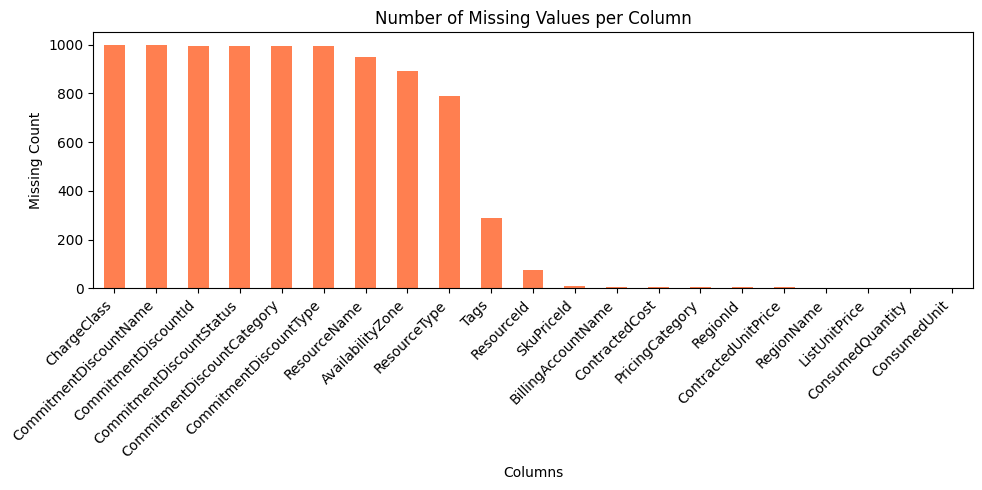

In [3]:
missing_counts = df.isna().sum()
# just wich has missing value
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_counts.plot(kind='bar', color='coral')
plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### create calculated columns

In [4]:
#1. Calculate total cost including estimated 15% tax
TAX_RATE = 0.15 
df['TaxAmount'] = df['BilledCost'] * TAX_RATE
df['TotalWithTax'] = df['BilledCost'] + df['TaxAmount']
# show a sample
df[['ServiceName', 'BilledCost', 'TaxAmount', 'TotalWithTax']].head(5)

,ServiceName,BilledCost,TaxAmount,TotalWithTax
0,Amazon Simple Queue Service,8.000000e-07,1.200000e-07,9.200000e-07
1,Elastic Load Balancing,1.605990e-05,2.408985e-06,1.846888e-05
2,Elastic Load Balancing,0.000000e+00,0.000000e+00,0.000000e+00
3,Amazon Elastic Compute Cloud,0.000000e+00,0.000000e+00,0.000000e+00
4,Elastic Load Balancing,4.137000e-07,6.205500e-08,4.757550e-07


In [5]:
#2. Calculate cost per usage unit
# Note: Adding a small number (1e-9) to avoid division by zero if PricingQuantity is 0
df['cost_per_unit'] = df['BilledCost'] / (df['PricingQuantity'] + 1e-9)

print("--- Sample with Cost Per Unit ---")
df[['ServiceName', 'BilledCost', 'PricingQuantity', 'cost_per_unit']].head()

--- Sample with Cost Per Unit ---


,ServiceName,BilledCost,PricingQuantity,cost_per_unit
0,Amazon Simple Queue Service,8.000000e-07,2.000000e+00,4.000000e-07
1,Elastic Load Balancing,1.605990e-05,2.007490e-03,7.999986e-03
2,Elastic Load Balancing,0.000000e+00,2.355203e-04,0.000000e+00
3,Amazon Elastic Compute Cloud,0.000000e+00,1.453000e-07,0.000000e+00
4,Elastic Load Balancing,4.137000e-07,6.895820e-05,5.999200e-03


### group data

In [6]:
#1. Group by service name, calculate total cost, and sort by highest spendin
service_summary = df.groupby('ServiceName')['BilledCost'].sum().sort_values(ascending=False).reset_index()
service_summary

,ServiceName,BilledCost
0,Amazon Elastic Compute Cloud,1.604169e+01
1,Azure Kubernetes Service,1.580880e+00
2,Amazon Relational Database Service,7.532271e-01
3,COMPUTE,5.360000e-01
4,Azure DB for MySQL,3.709677e-01
5,Red Hat OpenShift Service on AWS,3.420000e-01
6,Elastic Load Balancing,3.136842e-01
7,AmazonCloudWatch,2.201696e-01
8,Virtual Machines,1.756807e-01
9,Amazon Virtual Private Cloud,1.655403e-01


In [7]:
# 2. Group by CommitmentDiscountStatus and the sum of BilledCost
discount_summary = df.groupby('CommitmentDiscountStatus')['BilledCost'].sum().reset_index()

discount_summary

,CommitmentDiscountStatus,BilledCost
0,Used,0.0


### merge two small tables

In [8]:
#discount_summary table and service_summary table
merged_summary = pd.concat([service_summary.reset_index(drop=True), 
                            discount_summary.reset_index(drop=True)], 
                           axis=1)

print("final meraged table")
merged_summary

final meraged table


,ServiceName,BilledCost,CommitmentDiscountStatus,BilledCost
0,Amazon Elastic Compute Cloud,1.604169e+01,Used,0.0
1,Azure Kubernetes Service,1.580880e+00,NaN,NaN
2,Amazon Relational Database Service,7.532271e-01,NaN,NaN
3,COMPUTE,5.360000e-01,NaN,NaN
4,Azure DB for MySQL,3.709677e-01,NaN,NaN
5,Red Hat OpenShift Service on AWS,3.420000e-01,NaN,NaN
6,Elastic Load Balancing,3.136842e-01,NaN,NaN
7,AmazonCloudWatch,2.201696e-01,NaN,NaN
8,Virtual Machines,1.756807e-01,NaN,NaN
9,Amazon Virtual Private Cloud,1.655403e-01,NaN,NaN


### charts

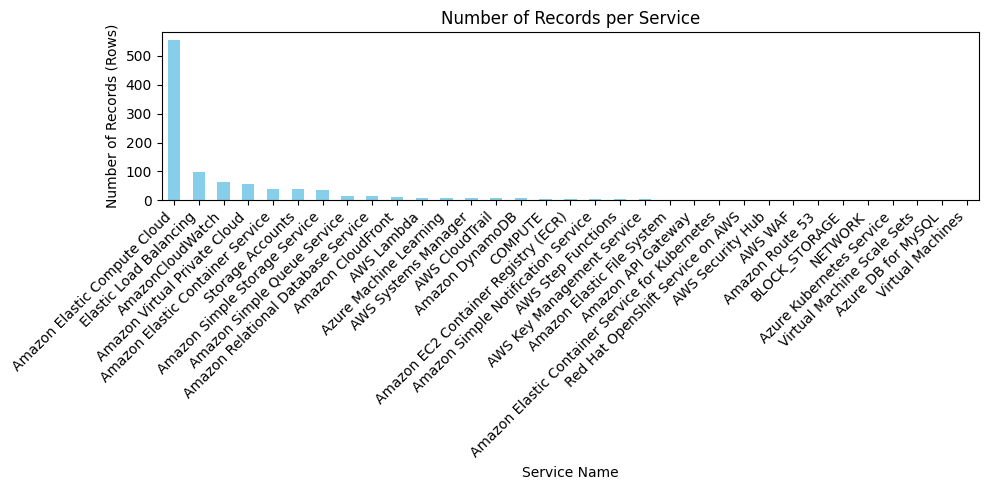

In [9]:
# number of records per service
service_counts = df['ServiceName'].value_counts()
plt.figure(figsize=(10, 5))
service_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Records per Service')
plt.xlabel('Service Name')
plt.ylabel('Number of Records (Rows)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

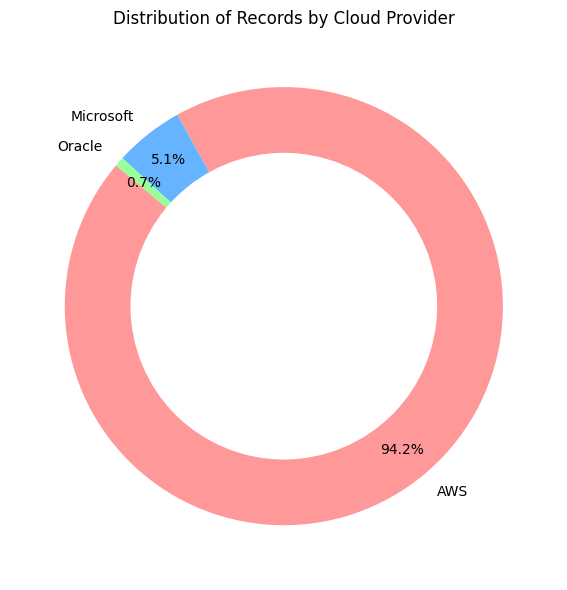

In [10]:
provider_counts = df['ProviderName'].value_counts()

# ProviderName Donut Chart
plt.figure(figsize=(6, 6))
plt.pie(
    provider_counts, 
    labels=provider_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    pctdistance=0.85,
    colors=['#ff9999', '#66b3ff', '#99ff99']
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Records by Cloud Provider')
plt.tight_layout()
plt.show()

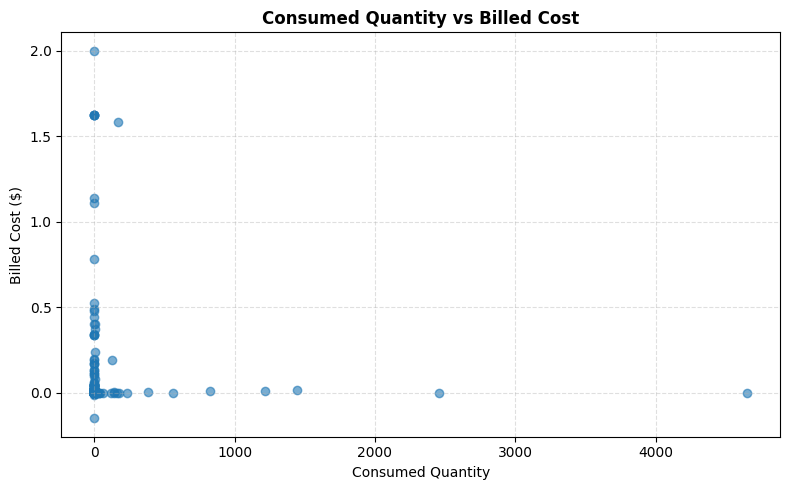

In [11]:
# scatte Consumed Quantity vs Billed Cost
plt.figure(figsize=(8, 5))
plt.scatter(df['ConsumedQuantity'], df['BilledCost'], color='#1f77b4', alpha=0.6)
plt.title('Consumed Quantity vs Billed Cost', fontsize=12, fontweight='bold')
plt.xlabel('Consumed Quantity')
plt.ylabel('Billed Cost ($)')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Summary & Next Steps

In this notebook, I explored the dataset structure and checked for missing values across all columns using basic stats and a missing value plot. 

I decided not to handle or fill the missing values (like those in `ChargeClass` or `Tags`) in this week's notebook. Instead, I am keeping the raw dataset as is for now and will handle all data cleaning, imputation, and missing value logic in **Week 3**.